In [58]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Cleaned_Dataset.csv")

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,No Coupon,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


In [5]:
df.shape

(1200, 14)

In [6]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       1200 non-null   object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [8]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [10]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

**Product Analysis**

In [13]:
product_counts = df["Product"].value_counts()
product_counts

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

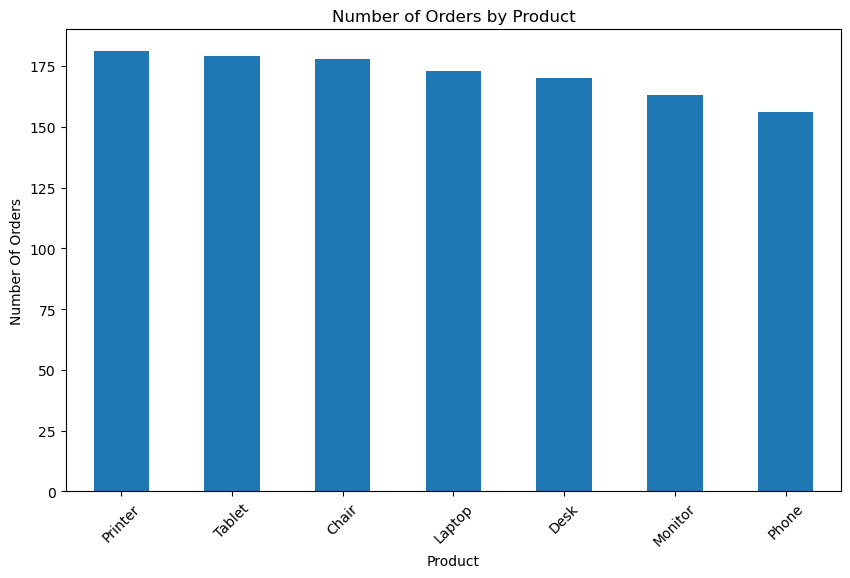

In [15]:
plt.figure(figsize=(10,6))
product_counts.plot(kind="bar")
plt.title("Number of Orders by Product")
plt.xlabel("Product")
plt.ylabel("Number Of Orders")
plt.xticks(rotation=45)
plt.show()

**Revenue Analysis**

In [18]:
#Calculate Total Revenue 
total_revenue = df["TotalPrice"].sum()
print("Total Revenue: ", total_revenue)

Total Revenue:  1264761.96


In [19]:
#Calculate Average order value 
average_order_value = df["TotalPrice"].mean()
print("Average Order Value: ", average_order_value)

Average Order Value:  1053.9683


In [21]:
# Calculate revenue by product
revenue_by_product = (df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False))
revenue_by_product

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

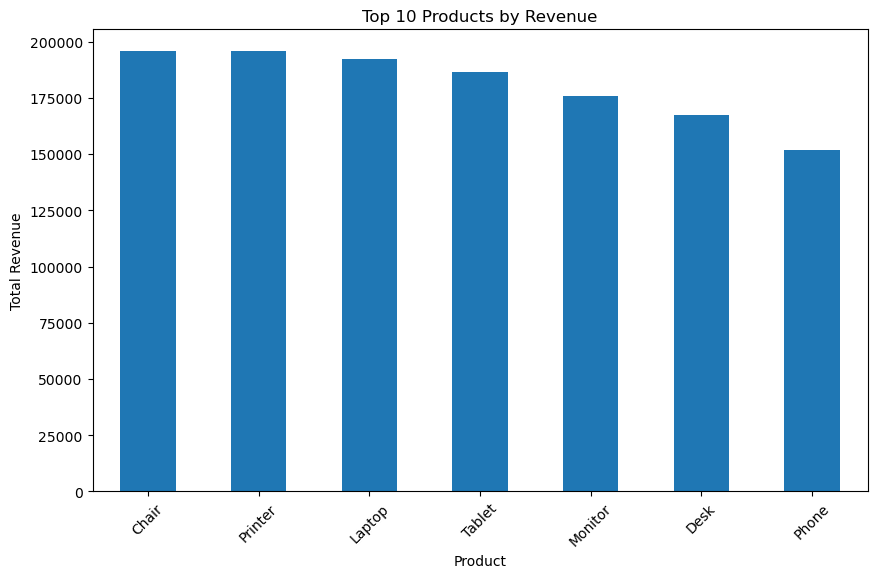

In [23]:
plt.figure(figsize=(10, 6))

revenue_by_product.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

**Time Analysis**

In [25]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

In [26]:
# Extract month from Date
df["Month"] = df["Date"].dt.to_period("M")

In [27]:
# Calculate the number of orders per month
monthly_orders = df.groupby("Month").size()
monthly_orders

Month
2023-01    47
2023-02    37
2023-03    43
2023-04    31
2023-05    49
2023-06    45
2023-07    44
2023-08    51
2023-09    29
2023-10    47
2023-11    41
2023-12    46
2024-01    32
2024-02    32
2024-03    36
2024-04    50
2024-05    34
2024-06    53
2024-07    43
2024-08    28
2024-09    44
2024-10    31
2024-11    35
2024-12    41
2025-01    27
2025-02    37
2025-03    49
2025-04    32
2025-05    37
2025-06    49
Freq: M, dtype: int64

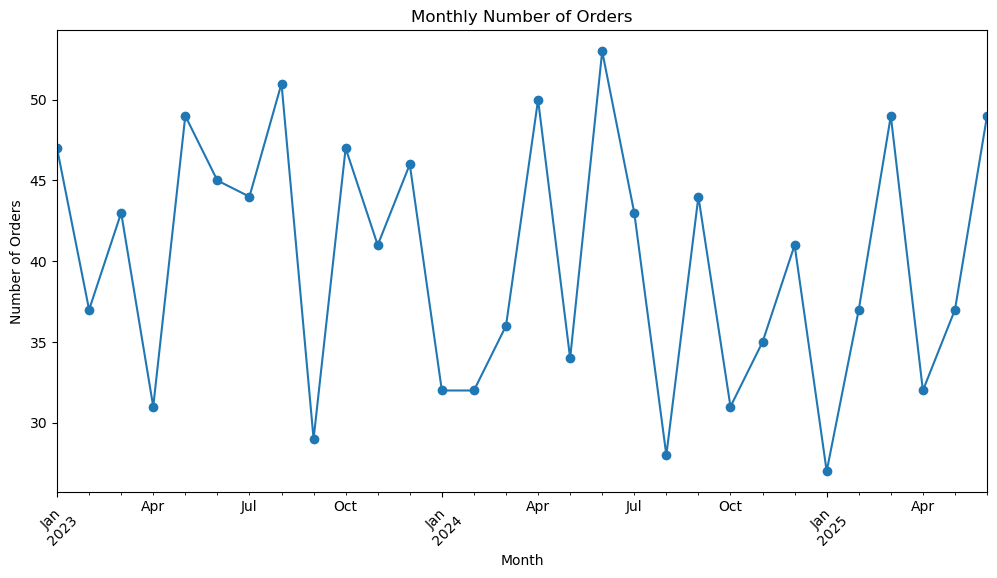

In [28]:
# Plot monthly orders
plt.figure(figsize=(12, 6))

monthly_orders.plot(kind="line", marker="o")

plt.title("Monthly Number of Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [29]:
#Calculate monthly revenue 
monthly_revenue = df.groupby("Month")["TotalPrice"].sum()
monthly_revenue

Month
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64

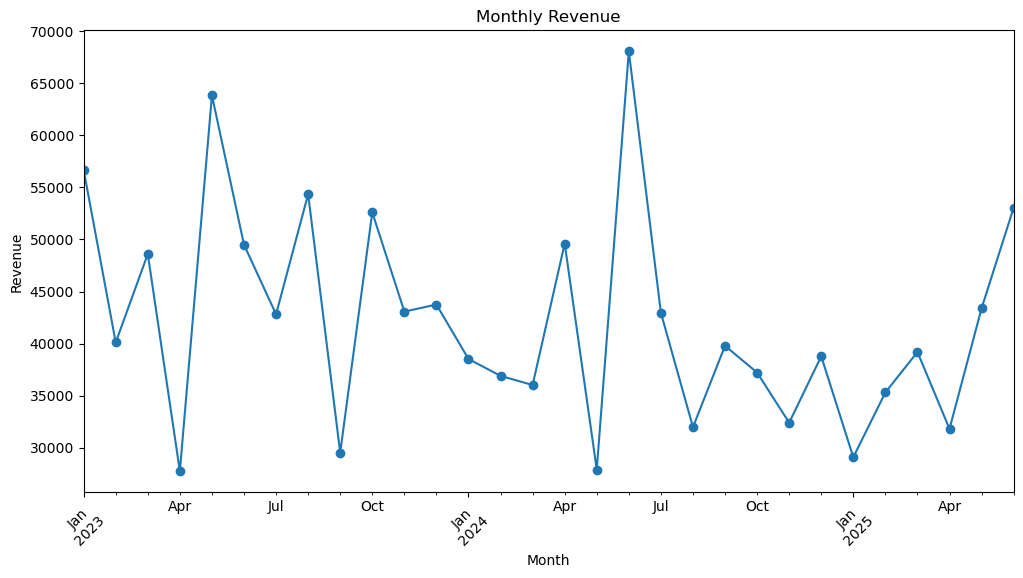

In [30]:
plt.figure(figsize=(12, 6))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

**Payment Method Analysis**

In [31]:
# Count orders by payment method 
payment_counts = df["PaymentMethod"].value_counts()
payment_counts

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

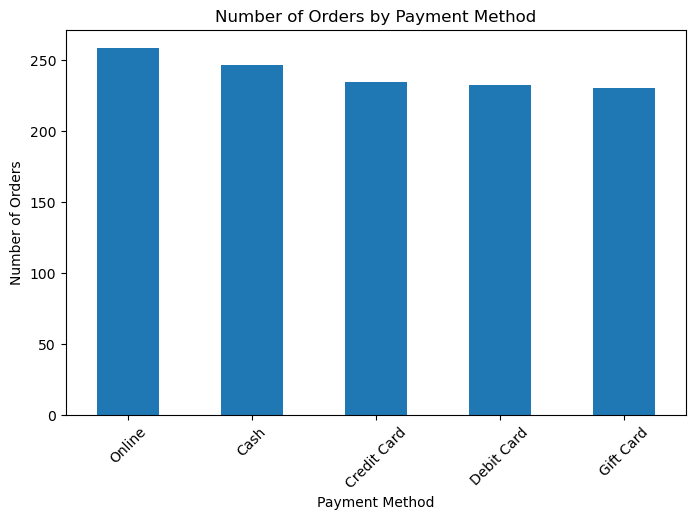

In [32]:
plt.figure(figsize=(8, 5))

payment_counts.plot(kind="bar")

plt.title("Number of Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [33]:
#Calculate revenue by payment method 
payment_revenue = (df.groupby("PaymentMethod")["TotalPrice"].sum().sort_values(ascending=False))
payment_revenue

PaymentMethod
Credit Card    263847.63
Online         262442.94
Cash           259786.29
Gift Card      246323.92
Debit Card     232361.18
Name: TotalPrice, dtype: float64

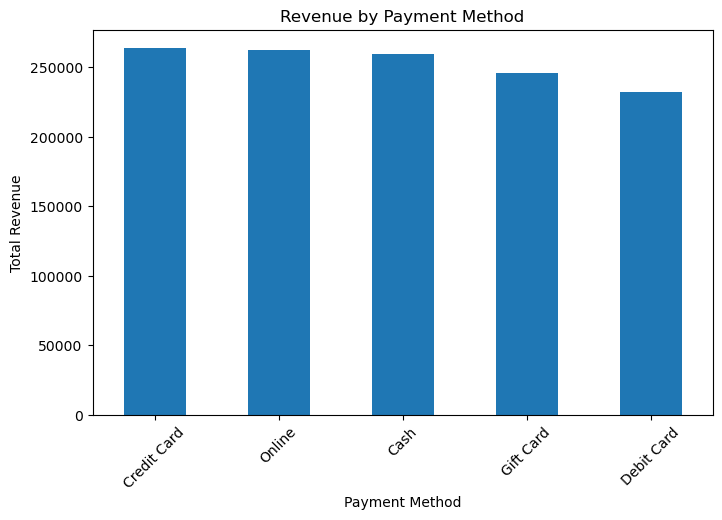

In [34]:
plt.figure(figsize=(8, 5))

payment_revenue.plot(kind="bar")

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

**Order Status Analysis**

In [36]:
# Count orders by order status
order_status_counts = df["OrderStatus"].value_counts()
order_status_counts

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

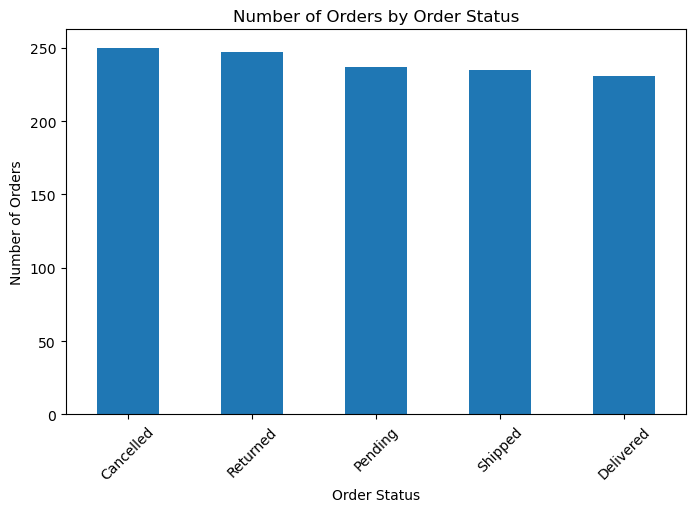

In [37]:
plt.figure(figsize=(8, 5))

order_status_counts.plot(kind="bar")

plt.title("Number of Orders by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [40]:
# Calculate revenue by order status
status_revenue = (df.groupby("OrderStatus")["TotalPrice"].sum().sort_values(ascending=False))
status_revenue

OrderStatus
Cancelled    276396.21
Pending      256328.15
Shipped      246159.58
Returned     243277.70
Delivered    242600.32
Name: TotalPrice, dtype: float64

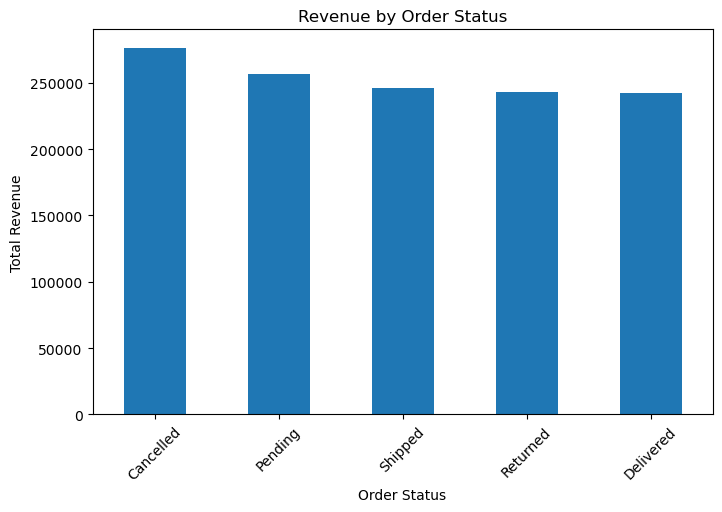

In [41]:
plt.figure(figsize=(8, 5))

status_revenue.plot(kind="bar")

plt.title("Revenue by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

In [42]:
status_percentage = df["OrderStatus"].value_counts(normalize=True) * 100 
status_percentage

OrderStatus
Cancelled    20.833333
Returned     20.583333
Pending      19.750000
Shipped      19.583333
Delivered    19.250000
Name: proportion, dtype: float64

In [63]:
# Calculate The Cancellation Rate 
cancellation_rate = ((df["OrderStatus"]=="Cancelled").mean()* 100)
print("Cancellation Rate:", round(cancellation_rate,2),"%")

Cancellation Rate: 20.83 %


**Coupon Analysis**

In [43]:
# Count orders by coupon code
coupon_counts = df["CouponCode"].value_counts()
coupon_counts

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

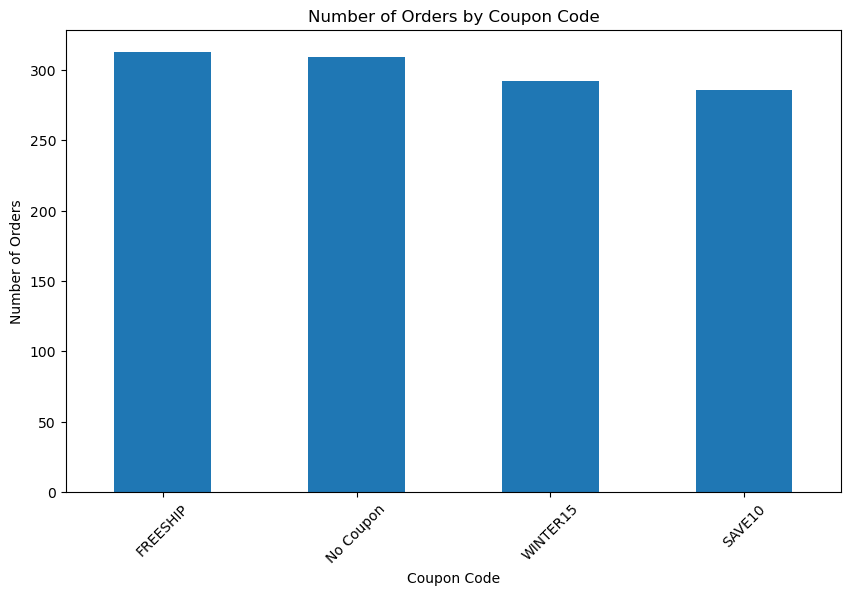

In [44]:
plt.figure(figsize=(10, 6))

coupon_counts.plot(kind="bar")

plt.title("Number of Orders by Coupon Code")
plt.xlabel("Coupon Code")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [45]:
# Calculate revenue by coupon code
coupon_revenue = (df.groupby("CouponCode")["TotalPrice"].sum().sort_values(ascending=False))
coupon_revenue

CouponCode
FREESHIP     335036.99
No Coupon    322401.41
SAVE10       304840.02
WINTER15     302483.54
Name: TotalPrice, dtype: float64

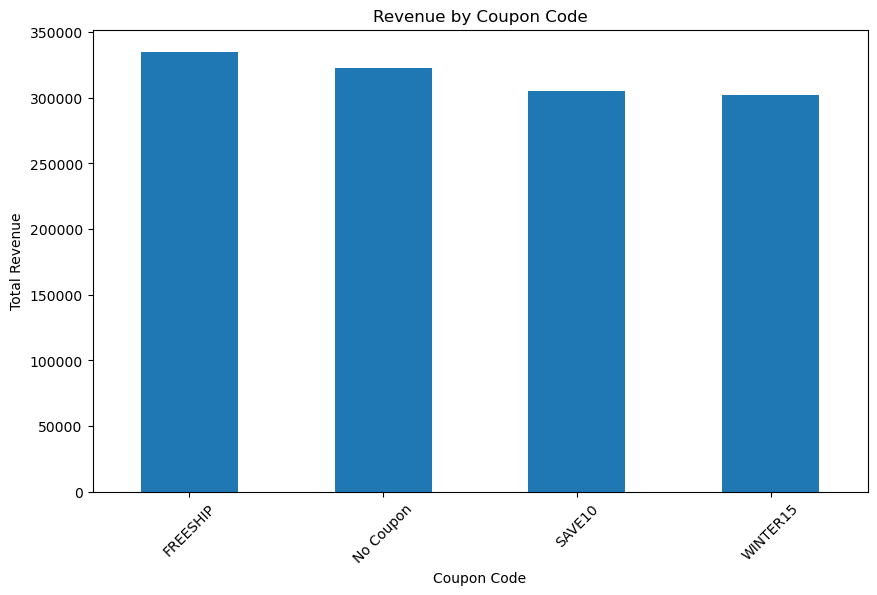

In [46]:
plt.figure(figsize=(10, 6))

coupon_revenue.plot(kind="bar")

plt.title("Revenue by Coupon Code")
plt.xlabel("Coupon Code")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.show()

In [47]:
#Create a coupon usage category 
df["CouponUsage"] = df["CouponCode"].apply(lambda x:"No Coupon" if x=="No Coupon" else "Used Coupon")
coupon_usage = df["CouponUsage"].value_counts()
coupon_usage

CouponUsage
Used Coupon    891
No Coupon      309
Name: count, dtype: int64

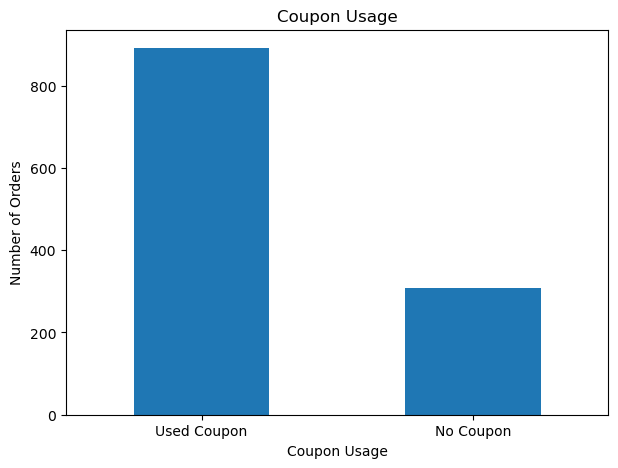

In [48]:
plt.figure(figsize=(7, 5))

coupon_usage.plot(kind="bar")

plt.title("Coupon Usage")
plt.xlabel("Coupon Usage")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.show()

**Referral Source Analysis**

In [49]:
# Count orders by referral source
referral_counts = df["ReferralSource"].value_counts()

referral_counts

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

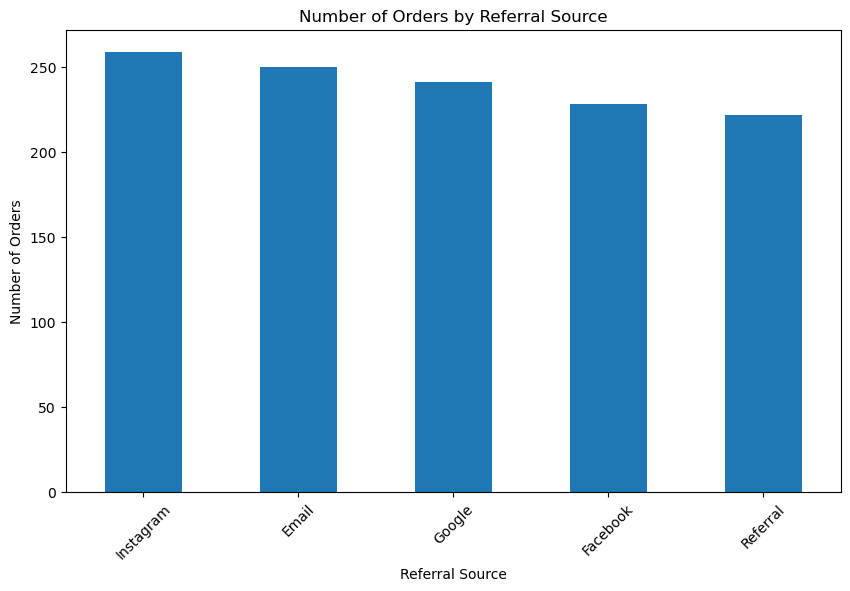

In [50]:
plt.figure(figsize=(10, 6))

referral_counts.plot(kind="bar")

plt.title("Number of Orders by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

In [51]:
# Calculate revenue by referral source
referral_revenue = (df.groupby("ReferralSource")["TotalPrice"].sum().sort_values(ascending=False))
referral_revenue

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

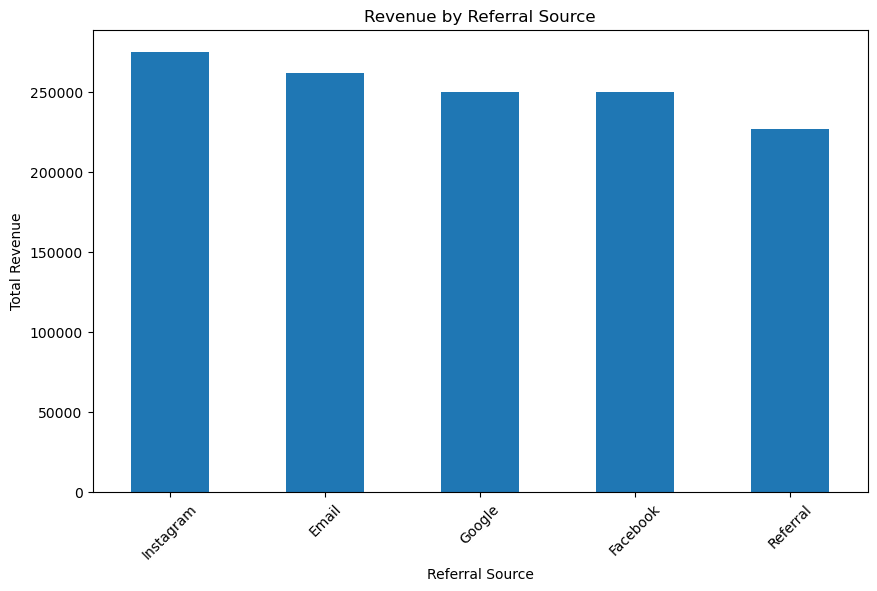

In [52]:
plt.figure(figsize=(10, 6))
referral_revenue.plot(kind="bar")
plt.title("Revenue by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [54]:
# Calculate average order value by referral source
avg_order_by_referral = (df.groupby("ReferralSource")["TotalPrice"].mean().sort_values(ascending=False))
avg_order_by_referral

ReferralSource
Facebook     1098.293421
Instagram    1062.878185
Email        1047.234200
Google       1039.176266
Referral     1021.691802
Name: TotalPrice, dtype: float64

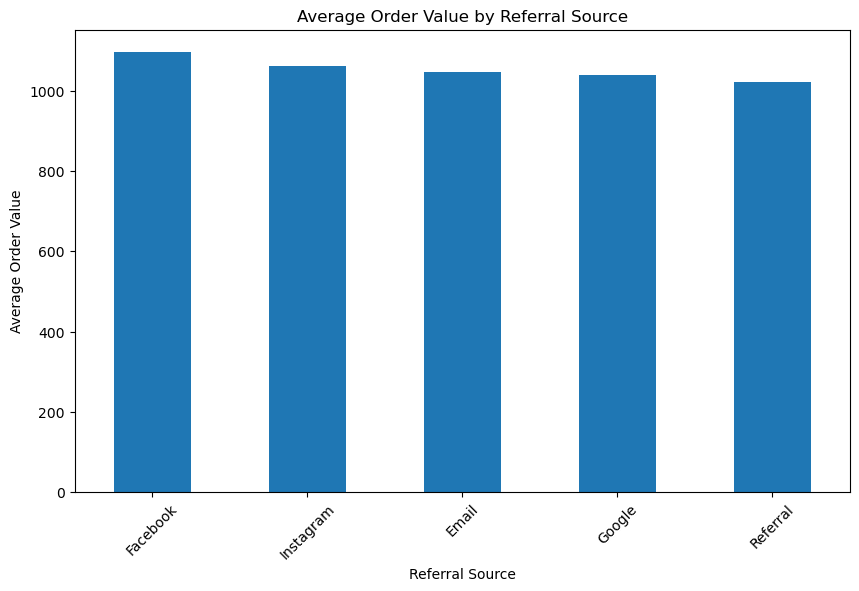

In [55]:
plt.figure(figsize=(10, 6))

avg_order_by_referral.plot(kind="bar")

plt.title("Average Order Value by Referral Source")
plt.xlabel("Referral Source")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)

plt.show()

**Correlation Analysis**

In [56]:
numeric_cols= ["Quantity", "UnitPrice", "TotalPrice"]
correlation_matrix = df[numeric_cols].corr()
correlation_matrix

,Quantity,UnitPrice,TotalPrice
Quantity,1.000000,0.014553,0.615251
UnitPrice,0.014553,1.000000,0.717081
TotalPrice,0.615251,0.717081,1.000000


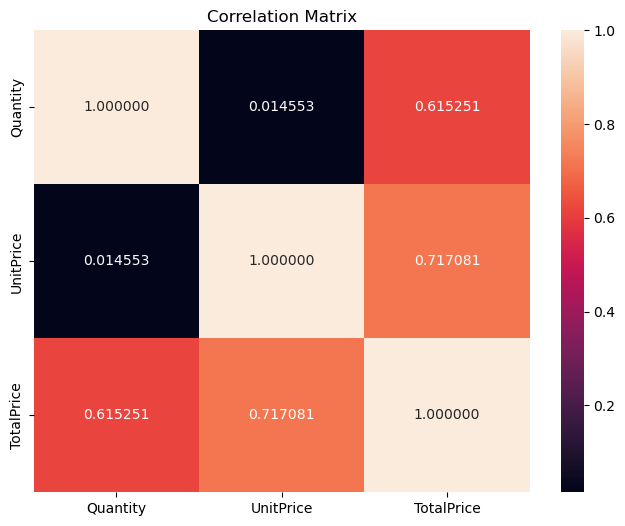

In [59]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,fmt="2f")
plt.title("Correlation Matrix")
plt.show()

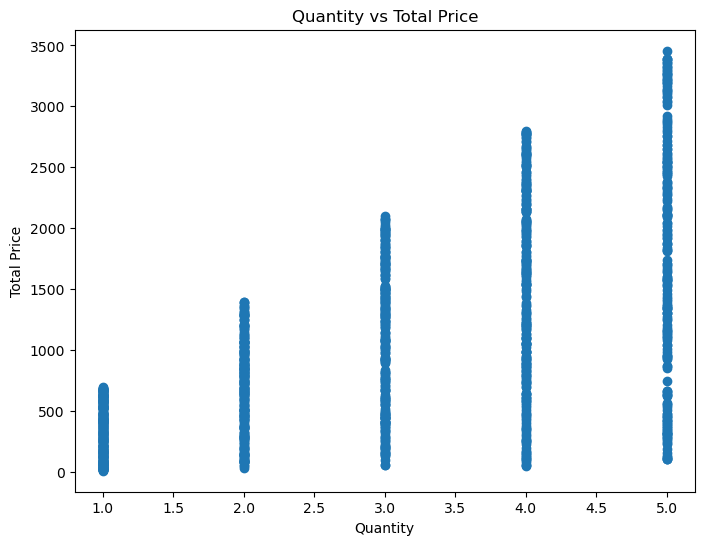

In [60]:
plt.figure(figsize=(8,6))
plt.scatter(df["Quantity"],df["TotalPrice"])
plt.title("Quantity vs Total Price")
plt.xlabel("Quantity")
plt.ylabel("Total Price")
plt.show()

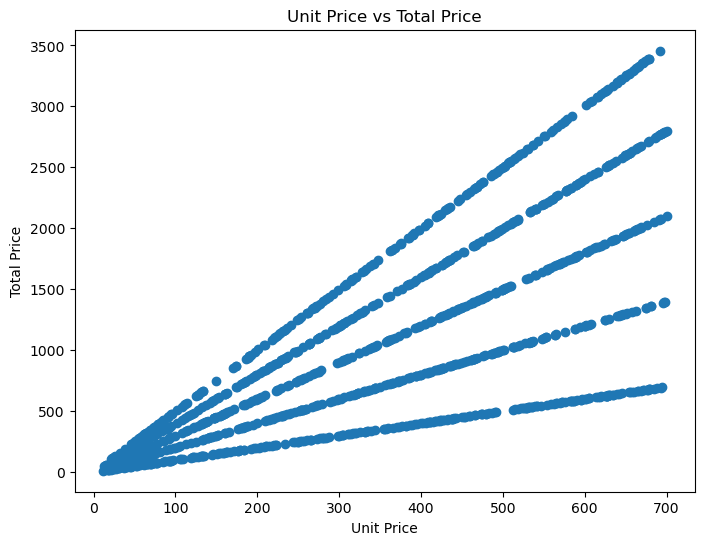

In [61]:
plt.figure(figsize=(8, 6))

plt.scatter(df["UnitPrice"], df["TotalPrice"])

plt.title("Unit Price vs Total Price")
plt.xlabel("Unit Price")
plt.ylabel("Total Price")

plt.show()

In [62]:
# Display key summary statistics for business insights

print("Total Revenue:", df["TotalPrice"].sum())
print("Average Order Value:", df["TotalPrice"].mean())
print("Total Orders:", len(df))

print("\nTop Product:")
print(df["Product"].value_counts().head(1))

print("\nMost Used Payment Method:")
print(df["PaymentMethod"].value_counts().head(1))

print("\nMost Common Referral Source:")
print(df["ReferralSource"].value_counts().head(1))

print("\nMost Common Order Status:")
print(df["OrderStatus"].value_counts().head(1))

Total Revenue: 1264761.96
Average Order Value: 1053.9683
Total Orders: 1200

Top Product:
Product
Printer    181
Name: count, dtype: int64

Most Used Payment Method:
PaymentMethod
Online    258
Name: count, dtype: int64

Most Common Referral Source:
ReferralSource
Instagram    259
Name: count, dtype: int64

Most Common Order Status:
OrderStatus
Cancelled    250
Name: count, dtype: int64


## Business Insights

### Overall Performance
- The dataset contains **1,200 orders**.
- The total revenue generated is **1,264,761.96**.
- The average order value is approximately **1,053.97**.

### Product Performance
- **Printer** is the top-selling product, with **181 orders**.
- This indicates that Printers have the highest order volume among the products in the dataset.

### Payment Analysis
- **Online** is the most commonly used payment method, with **258 orders**.
- This suggests that online payments are an important payment channel for customers.

### Marketing & Referral Analysis
- **Instagram** is the most common referral source, generating **259 orders**.
- This indicates that Instagram is an important customer acquisition channel in the dataset.

### Order Status Analysis
- **Cancelled** is the most common order status, with **250 orders**.
- The cancellation rate is approximately **20.83%** of all orders.
- This relatively high cancellation rate may indicate an opportunity to investigate the reasons behind cancelled orders and improve order completion.

### Key Takeaways
- The business generated more than **1.26 million** in total revenue from **1,200 orders**.
- **Printer** has the highest number of orders and is the leading product by order volume.
- **Online payments** are the most frequently used payment method.
- **Instagram** is the leading referral source and could be an important channel for marketing activities.
- The **20.83% cancellation rate** is a key area that may require further investigation to improve overall sales performance.